In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from quad_contraction_trajs import (
    TrajContext,
    TrajectoryType,
    TRAJ_REGISTRY,
)

t = np.linspace(0.0, 15.0, 2000)

In [37]:
# =====================================================
# Figure 1: original PX4 shapes (Set 1)
# =====================================================

def set1_spiral(t):
    R, T = 2.0, 7.5
    x = R * np.sin(2*np.pi*t/T)
    y = R * np.cos(2*np.pi*t/T)
    z = -3.0 * np.ones_like(t)
    return x, y, z

def set1_figure_eight(t):
    R, T = 2.0, 10.0
    x = R * np.sin(2*np.pi*t/T)
    y = R * np.sin(4*np.pi*t/T) / 2.0
    z = -3.0 * np.ones_like(t)
    return x, y, z

def set1_trefoil(t):
    R, T = 1.0, 15.0
    s = 2*np.pi*t/T
    x = R * (np.sin(s) + 2*np.sin(2*s))
    y = R * (np.cos(s) - 2*np.cos(2*s))
    z = -3.0 + 0.4 * (-np.sin(3*s))
    return x, y, z

def set1_fig8_heading(t):
    R, T = 1.5, 15.0
    s = 2*np.pi*t/T
    x = R * np.sin(s)
    y = R * np.sin(2*s) / 2.0
    z = -3.0 * np.ones_like(t)
    return x, y, z

set1_trajs = [
    ("Spiral", set1_spiral),
    ("Figure Eight", set1_figure_eight),
    ("Trefoil", set1_trefoil),
    ("Fig8 Heading", set1_fig8_heading),
]

In [ ]:
# =====================================================
# Figure 2: updated PX4 shapes (Set 2) — from quad_contraction_trajs
# =====================================================

ctx = TrajContext(sim=True)

def _eval_traj(traj_type, t_arr):
    """Evaluate a shared trajectory over a numpy time array."""
    fn = TRAJ_REGISTRY[traj_type]
    out = np.array([fn(float(ti), ctx) for ti in t_arr])
    return out[:, 0], out[:, 1], out[:, 2]

set2_trajs = [
    ("Spiral",       lambda t: _eval_traj(TrajectoryType.SPIRAL, t)),
    ("Figure Eight", lambda t: _eval_traj(TrajectoryType.FIGURE_EIGHT, t)),
    ("Trefoil",      lambda t: _eval_traj(TrajectoryType.TREFOIL, t)),
    ("Fig8 Heading", lambda t: _eval_traj(TrajectoryType.FIG8_HEADING, t)),
]

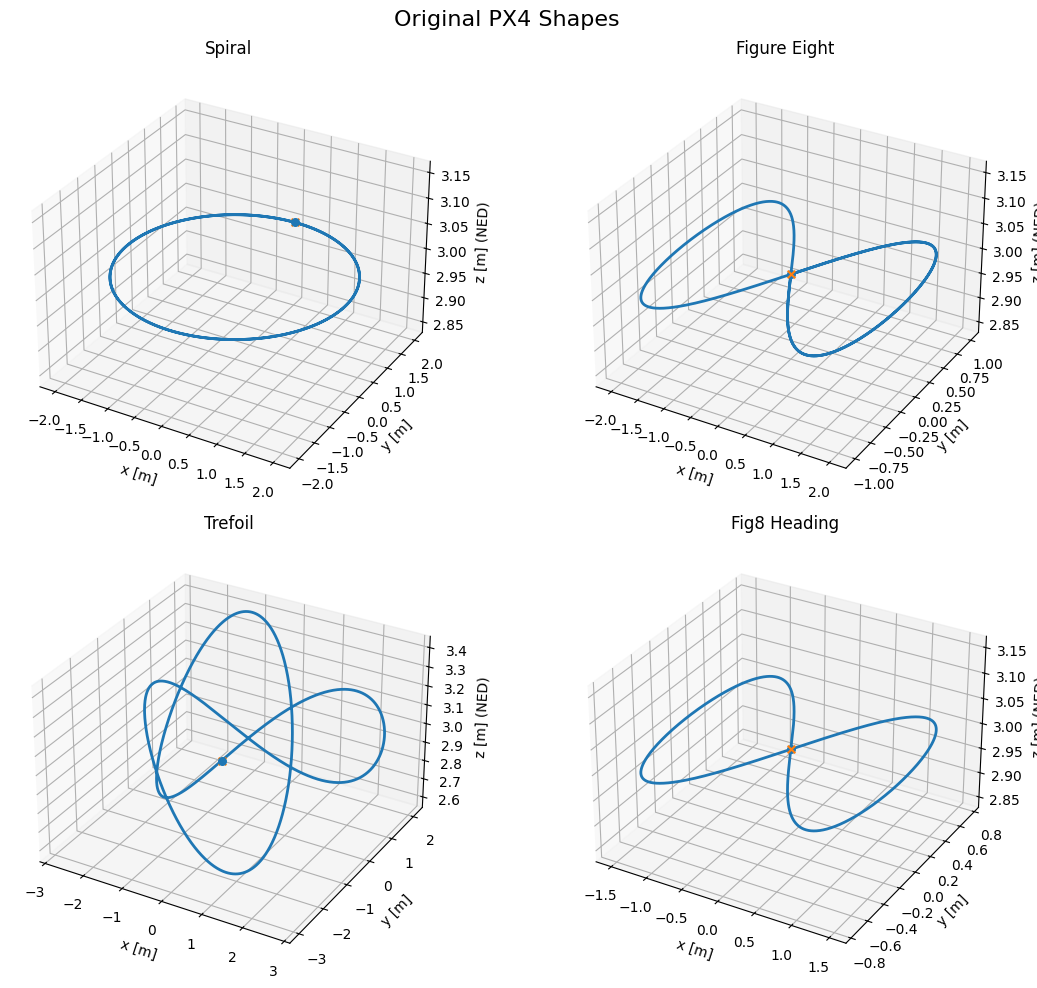

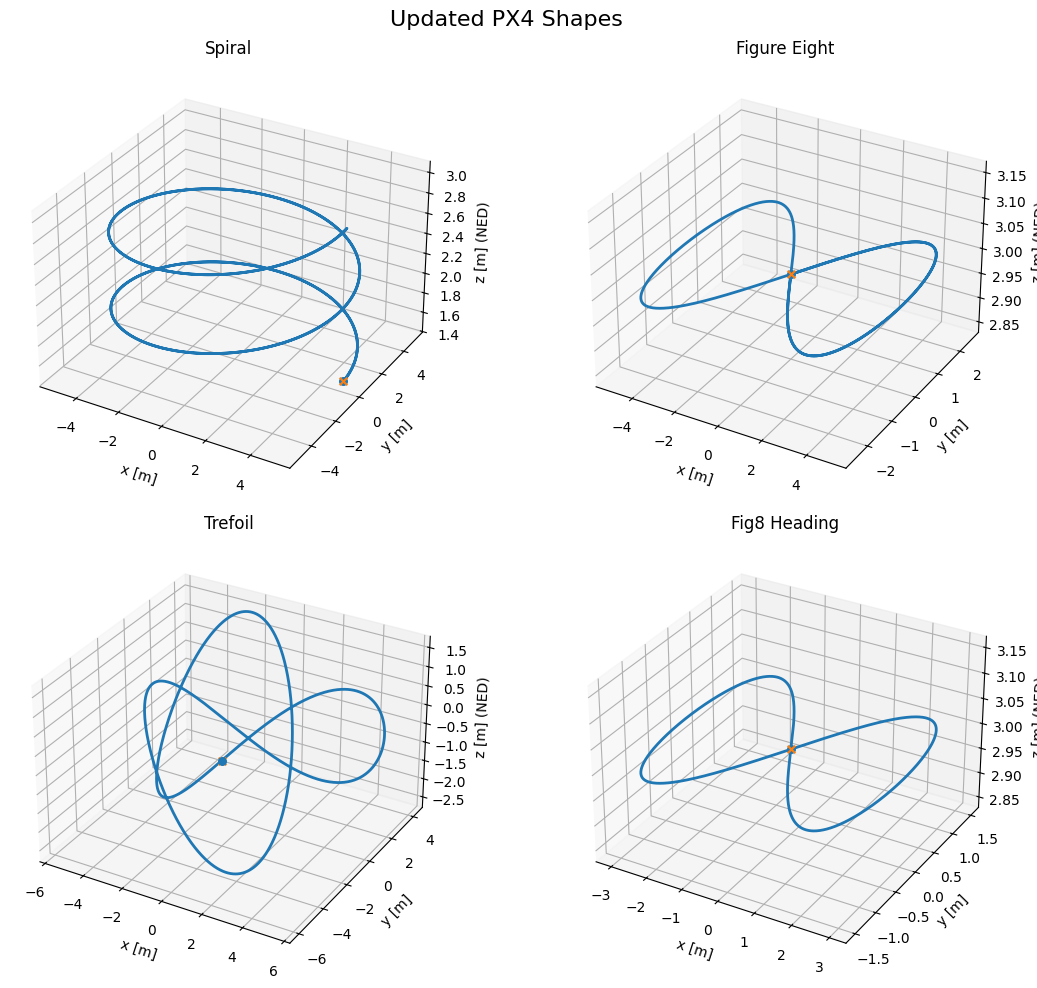

In [39]:
def plot_figure_grid(trajs, fig_title):
    fig = plt.figure(figsize=(12, 10))
    for i, (title, fn) in enumerate(trajs, start=1):
        ax = fig.add_subplot(2, 2, i, projection="3d")
        x, y, z = fn(t)
        ax.plot(x, y, -z, linewidth=2)
        ax.scatter(x[0], y[0], -z[0], s=30, label="start")
        ax.scatter(x[-1], y[-1], -z[-1], s=30, marker="x", label="end")
        ax.set_title(title)
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
        ax.set_zlabel("z [m] (NED)")
        ax.set_box_aspect((1, 1, 0.7))
        ax.grid(True)
    fig.suptitle(fig_title, fontsize=16)
    fig.tight_layout()
    plt.show()

plot_figure_grid(set1_trajs, "Original PX4 Shapes")
plot_figure_grid(set2_trajs, "Updated PX4 Shapes")